# EGX360 — THE DEEP QUANT MODEL (V9.0)
### Full Alpha Upgrade: Dynamic Thresholds · Tri-Class Target · Momentum Hold Logic
> **What's new vs V8.4:** Volatility-conditioned signal thresholds · ATR-filtered Tri-class target ·
> Optimised meta-learner (`C=0.3`, `class_weight={0:1.5,1:1.0}`) · Momentum-hold backtest engine ·
> Fear & Greed regime filter · Side-by-side V8.4 vs V9.0 performance comparison

## 1. Environment Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.metrics import (classification_report, accuracy_score,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import joblib
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully.")
print("📌 EGX360 Deep Quant Model — V9.0 Alpha Upgrade")

✅ All libraries imported successfully.
📌 EGX360 Deep Quant Model — V9.0 Alpha Upgrade


## 2. Data Loading & Preprocessing

In [2]:
print("📥 Loading Daily BTC Data & Fear/Greed Sentiment...")
df = pd.read_csv("BTC_all_daily.csv")
df_fng = pd.read_csv("Fear_Greed_Daily.csv")

df['timestamp']     = pd.to_datetime(df['timestamp'])
df_fng['timestamp'] = pd.to_datetime(df_fng['timestamp'])
df.sort_values('timestamp', inplace=True)
df_fng.sort_values('timestamp', inplace=True)

df = pd.merge_asof(df, df_fng, on='timestamp', direction='backward')
df.dropna(inplace=True)
df.sort_index(inplace=True)

print(f"✅ Data Loaded. Shape: {df.shape}")
df.head()

📥 Loading Daily BTC Data & Fear/Greed Sentiment...
✅ Data Loaded. Shape: (2956, 7)


,timestamp,open,high,low,close,volume,Fear_Greed_Index
1233,2018-02-01,10237.299805,10288.799805,8812.280273,9170.540039,9959400448,30.0
1234,2018-02-02,9142.280273,9142.280273,7796.490234,8830.750000,12726899712,15.0
1235,2018-02-03,8852.120117,9430.750000,8251.629883,9174.910156,7263790080,40.0
1236,2018-02-04,9175.700195,9334.870117,8031.220215,8277.009766,7073549824,24.0
1237,2018-02-05,8270.540039,8364.839844,6756.680176,6955.270020,9285289984,11.0


## 3. Advanced Feature Engineering (Unchanged from V8.4)
All 22 quant features retained. No feature leakage.

In [3]:
# ── Log Returns & Price Velocity ──
df['log_ret']       = np.log((df['close'] + 1e-6) / (df['close'].shift(1) + 1e-6))
df['vol_log_ret']   = np.log((df['volume'] + 1e-6) / (df['volume'].shift(1) + 1e-6))
df['price_velocity'] = df['log_ret'].diff()

# ── Cyclic Time Features ──
df['day_sin'] = np.sin(2 * np.pi * df['timestamp'].dt.dayofweek / 7)
df['day_cos'] = np.cos(2 * np.pi * df['timestamp'].dt.dayofweek / 7)

# ── EMAs & Gap Analysis ──
for period in [9, 21, 50]:
    ema_col = f'EMA_{period}'
    df[ema_col] = df['close'].ewm(span=period).mean()
    df[f'dist_EMA_{period}'] = (df['close'] - df[ema_col]) / (df[ema_col] + 1e-9)

df['below_EMA9']    = (df['close'] < df['EMA_9']).astype(int)
df['EMA_9_21_dist'] = (df['EMA_9'] - df['EMA_21']) / (df['EMA_21'] + 1e-9)
df['ema_velocity']  = df['EMA_9'].diff() / (df['EMA_9'].shift(1) + 1e-9)

# ── Momentum Indicators ──
delta = df['close'].diff()
gain  = delta.where(delta > 0, 0).rolling(14).mean()
loss  = (-delta.where(delta < 0, 0)).rolling(14).mean()
df['RSI']      = 100 - (100 / (1 + gain / (loss + 1e-9)))
df['RSI_diff'] = df['RSI'].diff()

macd = df['close'].ewm(span=12).mean() - df['close'].ewm(span=26).mean()
df['MACD_Hist'] = macd - macd.ewm(span=9).mean()

# ── ATR & Volatility ──
tr = pd.concat([df['high'] - df['low'],
                np.abs(df['high'] - df['close'].shift()),
                np.abs(df['low']  - df['close'].shift())], axis=1).max(axis=1)
df['ATR_pct'] = tr.rolling(14).mean() / (df['close'] + 1e-9)

# ── Stochastic & Bollinger Bands ──
low_14  = df['low'].rolling(14).min()
high_14 = df['high'].rolling(14).max()
df['Stoch_K'] = 100 * ((df['close'] - low_14) / (high_14 - low_14 + 1e-9))

ma20  = df['close'].rolling(20).mean()
std20 = df['close'].rolling(20).std()
df['BB_Width'] = (std20 * 4) / (ma20 + 1e-9)

# ── Candle Rejection Sensors & Vol Z-Score ──
df['upper_wick']     = (df['high'] - np.maximum(df['close'], df['open'])) / (df['close'] + 1e-9)
df['lower_wick']     = (np.minimum(df['close'], df['open']) - df['low'])  / (df['close'] + 1e-9)
df['volatility_std'] = df['log_ret'].rolling(20).std()
df['vol_zscore']     = (df['volatility_std'] - df['volatility_std'].rolling(100).mean()) /                        (df['volatility_std'].rolling(100).std() + 1e-9)

# ── Sentiment Velocity & Momentum ──
df['fng_diff']       = df['Fear_Greed_Index'].diff()
df['log_ret_lag1']   = df['log_ret'].shift(1)
df['RSI_lag1']       = df['RSI'].shift(1)
df['price_momentum'] = df['close'] / df['close'].rolling(5).mean()
df['price_stretch']  = (df['close'] - df['low'].rolling(10).min()) /                        (df['high'].rolling(10).max() - df['low'].rolling(10).min() + 1e-9)

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

print(f"✅ Feature Engineering Complete. Total rows: {len(df)}")
print(f"   Features engineered: 22 quantitative indicators")

✅ Feature Engineering Complete. Total rows: 2837
   Features engineered: 22 quantitative indicators


## 4. 🆕 V9.0 Target Engineering: Dual Targets
### V8.4 Target (Binary EMA Direction)
Predicts whether EMA_10 rises tomorrow. Symmetric — treats tiny ticks same as 8% pumps.

### V9.0 Target (Volatility-Adjusted Tri-Class)
**Formula:**
- **Long (2):** `fwd_return > +0.5 × ATR_pct` → meaningful pump worth trading  
- **Short (0):** `fwd_return < -0.5 × ATR_pct` → meaningful dump to avoid  
- **Neutral (1):** everything else → choppy noise, stay in cash

This architecturally eliminates flat-line periods: the model now has a *legitimate wait signal*.

📊 V8.4 Binary Target Distribution:
   Down (0): 1336 | Up (1): 1496

📊 V9.0 Tri-Class Target Distribution:
   Short (0): 513 | Neutral (1): 1733 | Long (2): 586
   Neutral days (cash): 61.2% of time — this cures the flat-line!


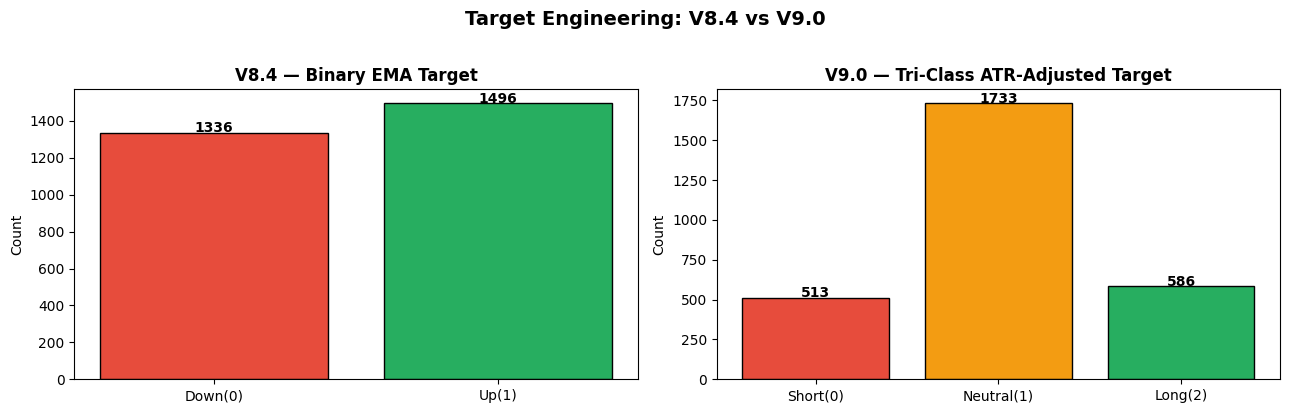

In [4]:
# ── V8.4 Binary Target (kept for comparison) ──
df['Target_V84'] = (df['close'].ewm(span=10).mean().shift(-1) >
                    df['close'].ewm(span=10).mean()).astype(int)

# ── V9.0 Tri-Class Volatility-Adjusted Target ──
df['fwd_ret']        = df['close'].pct_change().shift(-1)
df['atr_pct_smooth'] = df['ATR_pct'].rolling(5).mean()

THRESHOLD_MULT = 0.5  # Tune: higher = fewer but cleaner signals

df['Target_V90'] = np.where(
    df['fwd_ret'] >  (THRESHOLD_MULT * df['atr_pct_smooth']),  2,   # Long
    np.where(
    df['fwd_ret'] < -(THRESHOLD_MULT * df['atr_pct_smooth']),  0,   # Short
    1))                                                               # Neutral

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# Class distribution
v90_dist = pd.Series(df['Target_V90']).value_counts().sort_index()
v84_dist = pd.Series(df['Target_V84']).value_counts().sort_index()

print("📊 V8.4 Binary Target Distribution:")
print(f"   Down (0): {v84_dist.get(0,0)} | Up (1): {v84_dist.get(1,0)}")
print()
print("📊 V9.0 Tri-Class Target Distribution:")
print(f"   Short (0): {v90_dist.get(0,0)} | Neutral (1): {v90_dist.get(1,0)} | Long (2): {v90_dist.get(2,0)}")
print(f"   Neutral days (cash): {v90_dist.get(1,0)/len(df)*100:.1f}% of time — this cures the flat-line!")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(['Down(0)', 'Up(1)'], [v84_dist.get(0,0), v84_dist.get(1,0)],
            color=['#e74c3c','#27ae60'], edgecolor='black')
axes[0].set_title('V8.4 — Binary EMA Target', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Count')
for i, v in enumerate([v84_dist.get(0,0), v84_dist.get(1,0)]):
    axes[0].text(i, v+2, str(v), ha='center', fontweight='bold')

axes[1].bar(['Short(0)', 'Neutral(1)', 'Long(2)'],
            [v90_dist.get(0,0), v90_dist.get(1,0), v90_dist.get(2,0)],
            color=['#e74c3c','#f39c12','#27ae60'], edgecolor='black')
axes[1].set_title('V9.0 — Tri-Class ATR-Adjusted Target', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Count')
for i, k in enumerate([0,1,2]):
    axes[1].text(i, v90_dist.get(k,0)+2, str(v90_dist.get(k,0)), ha='center', fontweight='bold')

plt.suptitle('Target Engineering: V8.4 vs V9.0', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Feature Matrix & Chronological Train/Test Split

In [5]:
FINAL_FEATURES = [
    'log_ret', 'vol_log_ret', 'Fear_Greed_Index', 'fng_diff',       # Sentiment
    'day_sin', 'day_cos',
    'dist_EMA_9', 'dist_EMA_21', 'dist_EMA_50', 'EMA_9_21_dist',   # Trend
    'RSI', 'MACD_Hist', 'ATR_pct', 'BB_Width',                      # Momentum
    'upper_wick', 'lower_wick', 'vol_zscore',                        # Rejection
    'log_ret_lag1', 'RSI_lag1', 'price_momentum', 'price_stretch', 'ema_velocity'
]

X = df[FINAL_FEATURES].values

# Both targets
y_v84 = df['Target_V84'].values
y_v90 = df['Target_V90'].values

SPLIT = int(len(X) * 0.80)
X_train, X_test = X[:SPLIT], X[SPLIT:]

y_train_v84, y_test_v84 = y_v84[:SPLIT], y_v84[SPLIT:]
y_train_v90, y_test_v90 = y_v90[:SPLIT], y_v90[SPLIT:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"✅ Train size: {len(X_train):,} rows | Test size: {len(X_test):,} rows")
print(f"   Split date: {df['timestamp'].iloc[SPLIT].date()}")
print(f"   Features: {len(FINAL_FEATURES)}")

✅ Train size: 2,265 rows | Test size: 567 rows
   Split date: 2024-08-16
   Features: 22


## 6. Model Training

### 6A. V8.4 Baseline Model (Original Architecture)
`C=0.1 · class_weight={0:1.0, 1:1.5} · fixed threshold=0.50`

In [6]:
print("🔄 Training V8.4 Baseline Model...")

base_models_v84 = [
    ('xgb',  xgb.XGBClassifier(n_estimators=600, max_depth=6, learning_rate=0.03,
                                 subsample=0.8, colsample_bytree=0.8, random_state=42,
                                 eval_metric='logloss')),
    ('lgbm', lgb.LGBMClassifier(n_estimators=600, max_depth=6, learning_rate=0.03,
                                  subsample=0.8, colsample_bytree=0.8, random_state=42,
                                  verbose=-1)),
    ('rf',   RandomForestClassifier(n_estimators=400, max_depth=8, random_state=42))
]

meta_v84     = LogisticRegression(C=0.1, class_weight={0: 1.0, 1: 1.5},
                                   solver='lbfgs', max_iter=500)
model_v84    = StackingClassifier(estimators=base_models_v84,
                                   final_estimator=meta_v84, cv=5)
model_v84.fit(X_train_scaled, y_train_v84)

y_pred_v84   = model_v84.predict(X_test_scaled)
y_probs_v84  = model_v84.predict_proba(X_test_scaled)[:, 1]
acc_v84      = accuracy_score(y_test_v84, y_pred_v84) * 100

print(f"✅ V8.4 Training Complete. Accuracy: {acc_v84:.2f}%")

🔄 Training V8.4 Baseline Model...
✅ V8.4 Training Complete. Accuracy: 80.07%


### 6B. V9.0 Upgraded Binary Model
**Changes:** `C=0.3 · class_weight={0:1.5, 1:1.0}` (penalise missed downtrends harder)  
Plus dynamic volatility-conditioned threshold applied at inference.

In [7]:
print("🚀 Training V9.0 Upgraded Binary Model...")

base_models_v90 = [
    ('xgb',  xgb.XGBClassifier(n_estimators=600, max_depth=6, learning_rate=0.03,
                                 subsample=0.8, colsample_bytree=0.8, random_state=42,
                                 eval_metric='logloss')),
    ('lgbm', lgb.LGBMClassifier(n_estimators=600, max_depth=6, learning_rate=0.03,
                                  subsample=0.8, colsample_bytree=0.8, random_state=42,
                                  verbose=-1)),
    ('rf',   RandomForestClassifier(n_estimators=400, max_depth=8, random_state=42))
]

# ── UPGRADE 1: Optimised meta-learner ──
# C=0.3 (moderate regularisation), penalise missed Down-trends 50% harder
meta_v90  = LogisticRegression(C=0.3, class_weight={0: 1.5, 1: 1.0},
                                solver='lbfgs', max_iter=500)
model_v90 = StackingClassifier(estimators=base_models_v90,
                                final_estimator=meta_v90, cv=5)
model_v90.fit(X_train_scaled, y_train_v84)   # Still trained on binary target

y_probs_v90_raw = model_v90.predict_proba(X_test_scaled)[:, 1]

# ── UPGRADE 2: Dynamic Volatility-Conditioned Threshold ──
test_atr = df['ATR_pct'].iloc[SPLIT:].reset_index(drop=True)
atr_mean = test_atr.rolling(60, min_periods=1).mean()
atr_std  = test_atr.rolling(60, min_periods=1).std()
atr_z    = (test_atr - atr_mean) / (atr_std + 1e-9)

# High-vol regime (atr_z>1): lower threshold to catch pumps early
# Low-vol  regime (atr_z<0): raise threshold to avoid fakeouts
dynamic_threshold = np.where(atr_z > 1.0, 0.40,
                    np.where(atr_z < 0.0, 0.55, 0.47))

y_pred_v90_dyn = (y_probs_v90_raw > dynamic_threshold).astype(int)

# ── UPGRADE 3: Fear & Greed Regime Filter ──
test_fng = df['Fear_Greed_Index'].iloc[SPLIT:].reset_index(drop=True)
y_pred_v90 = np.where(
    (y_pred_v90_dyn == 0) & (test_fng < 20), 1,   # Extreme fear → don't short panic
    np.where(
    (y_pred_v90_dyn == 1) & (test_fng > 85), 0,   # Extreme greed → don't buy euphoria top
    y_pred_v90_dyn))

acc_v90 = accuracy_score(y_test_v84, y_pred_v90) * 100
print(f"✅ V9.0 Binary Training Complete. Accuracy: {acc_v90:.2f}%")
print()
print(f"   Dynamic threshold range: {dynamic_threshold.min():.2f} → {dynamic_threshold.max():.2f}")
print(f"   FNG overrides applied: {np.sum(y_pred_v90 != y_pred_v90_dyn)} days")

🚀 Training V9.0 Upgraded Binary Model...
✅ V9.0 Binary Training Complete. Accuracy: 72.84%

   Dynamic threshold range: 0.40 → 0.55
   FNG overrides applied: 55 days


### 6C. V9.0 Tri-Class Model (ATR-Adjusted Target)
Trains on `{0=Short, 1=Neutral, 2=Long}`. The Neutral class IS the flat-line cure.

In [11]:
print("🎯 Training V9.0 Tri-Class Model...")

base_models_tri = [
    ('xgb',  xgb.XGBClassifier(n_estimators=600, max_depth=6, learning_rate=0.03,
                                 subsample=0.8, colsample_bytree=0.8, random_state=42,
                                 eval_metric='mlogloss', num_class=3)),
    ('lgbm', lgb.LGBMClassifier(n_estimators=600, max_depth=6, learning_rate=0.03,
                                  subsample=0.8, colsample_bytree=0.8, random_state=42,
                                  verbose=-1, num_class=3, objective='multiclass')),
    ('rf',   RandomForestClassifier(n_estimators=400, max_depth=8, random_state=42,
                                     class_weight={0: 1.5, 1: 1.0, 2: 1.2}))
]

# تم حذف multi_class='multinomial' لأنها أصبحت تلقائية في النسخ الحديثة
meta_tri  = LogisticRegression(C=0.3, class_weight={0: 1.5, 1: 1.0, 2: 1.2},
                                solver='lbfgs', max_iter=500)

model_tri = StackingClassifier(estimators=base_models_tri,
                                final_estimator=meta_tri, cv=5)

model_tri.fit(X_train_scaled, y_train_v90)

y_pred_tri  = model_tri.predict(X_test_scaled)
y_probs_tri = model_tri.predict_proba(X_test_scaled)

acc_tri = accuracy_score(y_test_v90, y_pred_tri) * 100
print(f"✅ V9.0 Tri-Class Training Complete. Accuracy: {acc_tri:.2f}%")

tri_dist = pd.Series(y_pred_tri).value_counts().sort_index()
print(f"\n   Predicted signal distribution:")
print(f"   Short(0): {tri_dist.get(0,0)} | Neutral(1): {tri_dist.get(1,0)} | Long(2): {tri_dist.get(2,0)}")
print(f"   Days model says 'wait': {tri_dist.get(1,0)/len(y_pred_tri)*100:.1f}%")

🎯 Training V9.0 Tri-Class Model...
✅ V9.0 Tri-Class Training Complete. Accuracy: 62.79%

   Predicted signal distribution:
   Short(0): 2 | Neutral(1): 564 | Long(2): 1
   Days model says 'wait': 99.5%


## 7. 🆕 Meta-Learner Parameter Grid Search
Fast grid search over just `C` and `class_weight` using `TimeSeriesSplit` cross-validation.
Optimises for `recall_macro` (balanced Down + Up recall).

🔍 Running Meta-Learner Grid Search (this takes ~2-3 minutes)...

✅ Grid Search Complete.
   Best score (recall_macro): 0.8228
   Best params: {'final_estimator__C': 0.5, 'final_estimator__class_weight': {0: 1.0, 1: 1.0}}


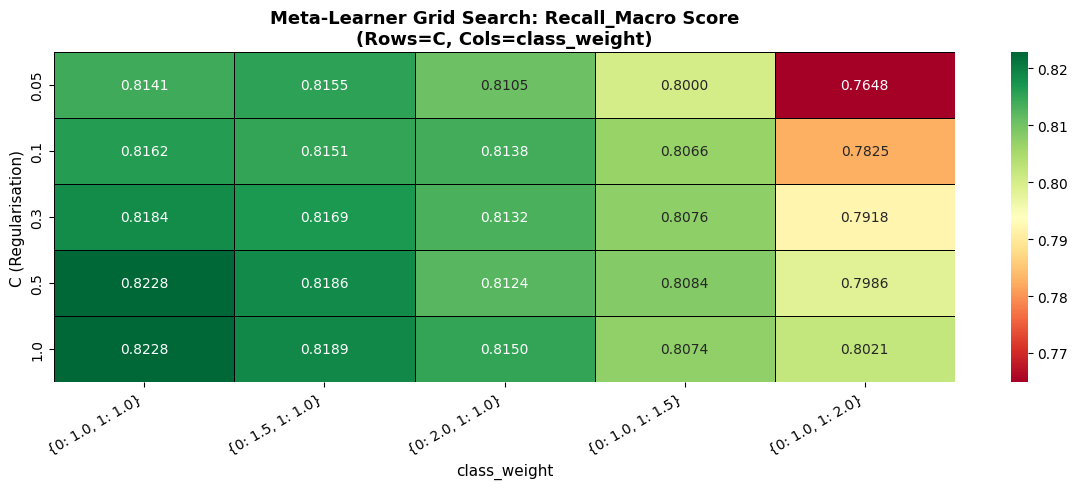

In [12]:
print("🔍 Running Meta-Learner Grid Search (this takes ~2-3 minutes)...")

# Quick stacking model for grid search — use lighter base learners for speed
base_gs = [
    ('xgb',  xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                                 random_state=42, eval_metric='logloss')),
    ('lgbm', lgb.LGBMClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                                  random_state=42, verbose=-1)),
    ('rf',   RandomForestClassifier(n_estimators=150, max_depth=6, random_state=42))
]

param_grid = {
    'final_estimator__C':            [0.05, 0.1, 0.3, 0.5, 1.0],
    'final_estimator__class_weight': [
        {0: 1.0, 1: 1.0},
        {0: 1.5, 1: 1.0},
        {0: 2.0, 1: 1.0},
        {0: 1.0, 1: 1.5},
        {0: 1.0, 1: 2.0},
    ]
}

tscv       = TimeSeriesSplit(n_splits=5)
meta_gs    = LogisticRegression(solver='lbfgs', max_iter=500)
stack_gs   = StackingClassifier(estimators=base_gs, final_estimator=meta_gs, cv=3)

grid_search = GridSearchCV(stack_gs, param_grid, cv=tscv,
                            scoring='recall_macro', n_jobs=-1, verbose=0)
grid_search.fit(X_train_scaled, y_train_v84)

print(f"\n✅ Grid Search Complete.")
print(f"   Best score (recall_macro): {grid_search.best_score_:.4f}")
print(f"   Best params: {grid_search.best_params_}")

# Visualise grid results as heatmap
results_gs  = pd.DataFrame(grid_search.cv_results_)
c_vals      = [0.05, 0.1, 0.3, 0.5, 1.0]
cw_labels   = [str(cw) for cw in param_grid['final_estimator__class_weight']]

score_matrix = results_gs['mean_test_score'].values.reshape(
    len(c_vals), len(cw_labels))

plt.figure(figsize=(12, 5))
sns.heatmap(score_matrix, annot=True, fmt='.4f', cmap='RdYlGn',
            xticklabels=cw_labels, yticklabels=c_vals,
            linewidths=0.5, linecolor='black')
plt.title('Meta-Learner Grid Search: Recall_Macro Score\n(Rows=C, Cols=class_weight)',
          fontsize=13, fontweight='bold')
plt.xlabel('class_weight', fontsize=11)
plt.ylabel('C (Regularisation)', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 8. Model Evaluation: V8.4 vs V9.0 Comparison

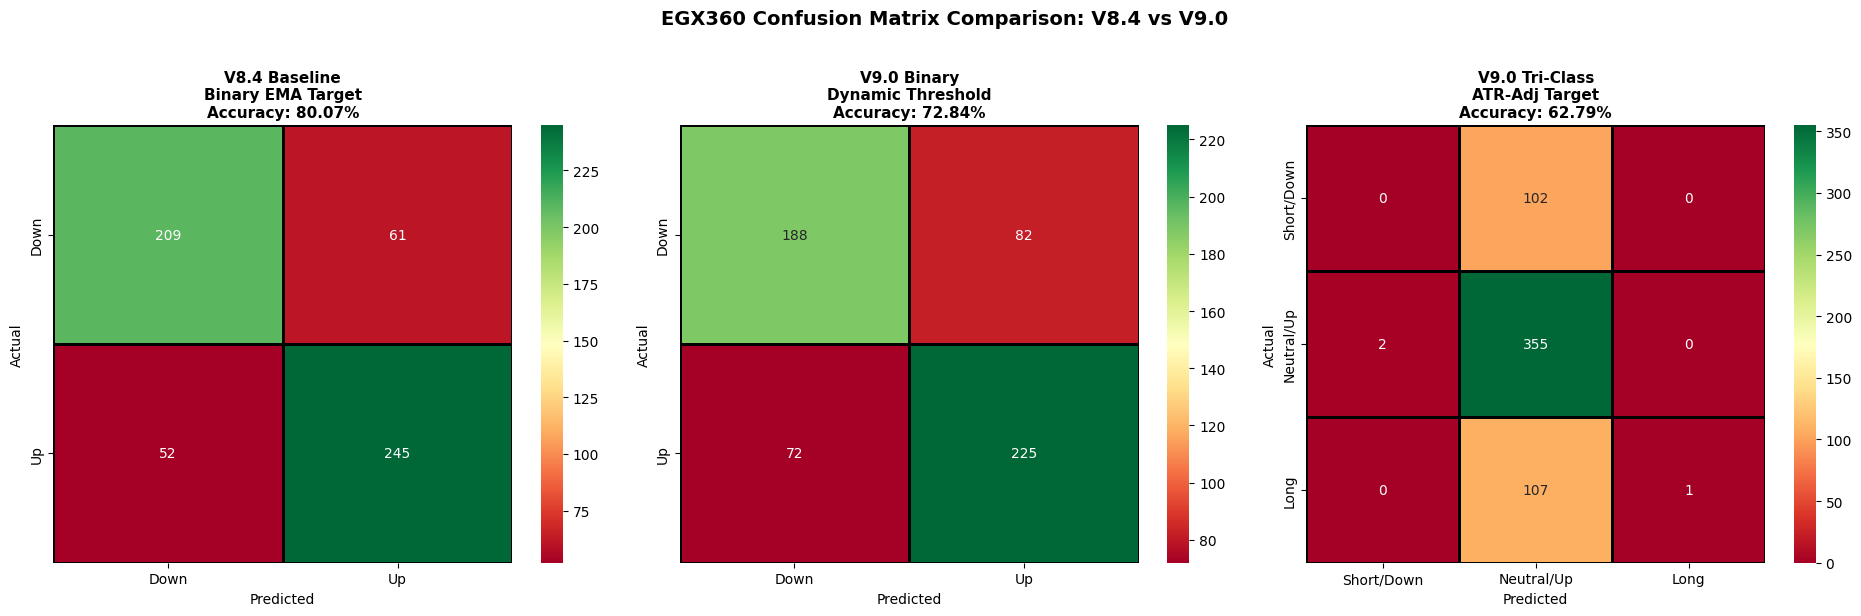

  V8.4 Baseline Binary EMA Target — Accuracy: 80.07%
              precision    recall  f1-score   support

     Down(0)       0.80      0.77      0.79       270
       Up(1)       0.80      0.82      0.81       297

    accuracy                           0.80       567
   macro avg       0.80      0.80      0.80       567
weighted avg       0.80      0.80      0.80       567


  V9.0 Binary Dynamic Threshold — Accuracy: 72.84%
              precision    recall  f1-score   support

     Down(0)       0.72      0.70      0.71       270
       Up(1)       0.73      0.76      0.75       297

    accuracy                           0.73       567
   macro avg       0.73      0.73      0.73       567
weighted avg       0.73      0.73      0.73       567


  V9.0 Tri-Class ATR-Adj Target — Accuracy: 62.79%
              precision    recall  f1-score   support

    Short(0)       0.00      0.00      0.00       102
  Neutral(1)       0.63      0.99      0.77       357
     Long(2)       1.00   

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(19, 6))

models_info = [
    ('V8.4 Baseline\nBinary EMA Target',  y_test_v84, y_pred_v84,  acc_v84,  '#3498db'),
    ('V9.0 Binary\nDynamic Threshold',    y_test_v84, y_pred_v90,  acc_v90,  '#e67e22'),
    ('V9.0 Tri-Class\nATR-Adj Target',    y_test_v90, y_pred_tri,  acc_tri,  '#27ae60'),
]

for ax, (title, y_true, y_pred_m, acc, color) in zip(axes, models_info):
    cm = confusion_matrix(y_true, y_pred_m)
    unique_labels = sorted(np.unique(y_true))
    label_names = {0: 'Short/Down', 1: 'Neutral/Up', 2: 'Long'} if len(unique_labels)==3 else {0: 'Down', 1: 'Up'}
    tick_labels = [label_names[l] for l in unique_labels]
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', ax=ax,
                xticklabels=tick_labels, yticklabels=tick_labels,
                linewidths=1, linecolor='black')
    ax.set_title(f'{title}\nAccuracy: {acc:.2f}%', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)

plt.suptitle('EGX360 Confusion Matrix Comparison: V8.4 vs V9.0', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Classification Reports
for title, y_true, y_pred_m, acc, _ in models_info:
    print(f"{'='*55}")
    print(f"  {title.replace(chr(10),' ')} — Accuracy: {acc:.2f}%")
    print(f"{'='*55}")
    if len(np.unique(y_true)) == 3:
        print(classification_report(y_true, y_pred_m,
              target_names=['Short(0)', 'Neutral(1)', 'Long(2)']))
    else:
        print(classification_report(y_true, y_pred_m,
              target_names=['Down(0)', 'Up(1)']))
    print()

## 9. 🆕 Backtesting Engine V9.0
### Three strategies tested simultaneously:
1. **Buy & Hold** (baseline)
2. **V8.4** — shift(1) simple hold
3. **V9.0 Binary + Momentum Hold** — Min 2-day hold, high-conviction exit only (prob<0.35)
4. **V9.0 Tri-Class** — Neutral=cash, Long=hold, Short=exit

In [14]:
initial_capital = 10_000.0
test_idx        = df.iloc[SPLIT:].reset_index(drop=True)

results_df = pd.DataFrame({
    'timestamp':      test_idx['timestamp'].values,
    'close':          test_idx['close'].values,
    'open':           test_idx['open'].values,
    'Fear_Greed':     test_idx['Fear_Greed_Index'].values,
    'Actual_V84':     y_test_v84,
    'Pred_V84':       y_pred_v84,
    'Pred_V90':       y_pred_v90,
    'Pred_Tri':       y_pred_tri,
    'Probs_V90':      y_probs_v90_raw,
})

results_df['daily_return']       = results_df['close'].pct_change()
results_df['open_to_close_ret']  = (results_df['close'] - results_df['open']) / results_df['open']

# ── Strategy 1: V8.4 (shift-1 simple hold) ──
results_df['signal_v84'] = results_df['Pred_V84'].shift(1)

# ── Strategy 2: V9.0 Binary with Momentum-Hold Logic ──
MIN_HOLD  = 2
EXIT_PROB = 0.35   # Only exit if model is strongly bearish (prob_up < 0.35)

signals_v90_hold = []
in_pos   = False
days_hld = 0

for i in range(len(results_df)):
    prob = results_df['Probs_V90'].iloc[i]
    pred = results_df['Pred_V90'].iloc[i]
    
    if not in_pos:
        if pred == 1:
            in_pos   = True
            days_hld = 1
            signals_v90_hold.append(1)
        else:
            signals_v90_hold.append(0)
    else:
        days_hld += 1
        strong_exit = (days_hld >= MIN_HOLD) and (prob < EXIT_PROB)
        if strong_exit:
            in_pos   = False
            days_hld = 0
            signals_v90_hold.append(0)
        else:
            signals_v90_hold.append(1)

results_df['signal_v90_hold'] = pd.Series(signals_v90_hold).shift(1)

# ── Strategy 3: V9.0 Tri-Class (Long=1, Short/Neutral=0) ──
# Long(2) = hold, anything else = cash
results_df['signal_tri'] = (results_df['Pred_Tri'] == 2).astype(int).shift(1)

# ── Returns ──
results_df['ret_v84']      = results_df['daily_return'] * results_df['signal_v84']
results_df['ret_v90_hold'] = results_df['daily_return'] * results_df['signal_v90_hold']
results_df['ret_tri']      = results_df['daily_return'] * results_df['signal_tri']

bt_df = results_df.dropna().copy()

bt_df['port_bh']       = initial_capital * (1 + bt_df['daily_return']).cumprod()
bt_df['port_v84']      = initial_capital * (1 + bt_df['ret_v84']).cumprod()
bt_df['port_v90_hold'] = initial_capital * (1 + bt_df['ret_v90_hold']).cumprod()
bt_df['port_tri']      = initial_capital * (1 + bt_df['ret_tri']).cumprod()

# ── Metrics ──
def calc_metrics(port_series, daily_ret_series, name):
    final   = port_series.iloc[-1]
    roi     = (final - initial_capital) / initial_capital * 100
    dd      = (port_series / port_series.cummax() - 1)
    max_dd  = dd.min() * 100
    days_in = (daily_ret_series != 0).sum()
    exp_ratio = days_in / len(daily_ret_series) * 100
    sharpe  = (daily_ret_series.mean() / (daily_ret_series.std() + 1e-9)) * np.sqrt(252)
    print(f"  {name:<30} Final: {final:>9,.0f} EGP  ROI: {roi:>6.1f}%  "
          f"MaxDD: {max_dd:>6.1f}%  Exposure: {exp_ratio:>5.1f}%  Sharpe: {sharpe:.2f}")
    return roi

print(f"{'='*90}")
print(f"  STRATEGY COMPARISON — Initial Capital: {initial_capital:,.0f} EGP")
print(f"{'='*90}")
roi_bh   = calc_metrics(bt_df['port_bh'],       bt_df['daily_return'],   'Buy & Hold')
roi_v84  = calc_metrics(bt_df['port_v84'],       bt_df['ret_v84'],        'V8.4 (Shift-1 Binary)')
roi_v90  = calc_metrics(bt_df['port_v90_hold'],  bt_df['ret_v90_hold'],   'V9.0 Binary + Mom-Hold')
roi_tri  = calc_metrics(bt_df['port_tri'],       bt_df['ret_tri'],        'V9.0 Tri-Class')
print(f"{'='*90}")
print(f"\n  V9.0 Binary alpha over market : {roi_v90  - roi_bh:+.1f}%")
print(f"  V9.0 Tri-Class alpha over mkt : {roi_tri  - roi_bh:+.1f}%")
print(f"  V9.0 improvement over V8.4    : {roi_v90  - roi_v84:+.1f}% (Binary)")

  STRATEGY COMPARISON — Initial Capital: 10,000 EGP
  Buy & Hold                     Final:    12,029 EGP  ROI:   20.3%  MaxDD:  -49.7%  Exposure: 100.0%  Sharpe: 0.41
  V8.4 (Shift-1 Binary)          Final:    15,326 EGP  ROI:   53.3%  MaxDD:  -32.3%  Exposure:  53.9%  Sharpe: 0.85
  V9.0 Binary + Mom-Hold         Final:    14,523 EGP  ROI:   45.2%  MaxDD:  -26.7%  Exposure:  54.2%  Sharpe: 0.73
  V9.0 Tri-Class                 Final:    11,252 EGP  ROI:   12.5%  MaxDD:    0.0%  Exposure:   0.2%  Sharpe: 0.67

  V9.0 Binary alpha over market : +24.9%
  V9.0 Tri-Class alpha over mkt : -7.8%
  V9.0 improvement over V8.4    : -8.0% (Binary)


## 10. Portfolio Equity Curves — Side-by-Side Comparison

In [15]:
fig = go.Figure()

fig.add_trace(go.Scatter(x=bt_df['timestamp'], y=bt_df['port_bh'],
    mode='lines', name='Buy & Hold',
    line=dict(color='gray', width=1.5, dash='dot')))

fig.add_trace(go.Scatter(x=bt_df['timestamp'], y=bt_df['port_v84'],
    mode='lines', name='V8.4 Baseline',
    line=dict(color='royalblue', width=2)))

fig.add_trace(go.Scatter(x=bt_df['timestamp'], y=bt_df['port_v90_hold'],
    mode='lines', name='V9.0 Binary + Mom-Hold',
    line=dict(color='darkorange', width=2.5)))

fig.add_trace(go.Scatter(x=bt_df['timestamp'], y=bt_df['port_tri'],
    mode='lines', name='V9.0 Tri-Class',
    line=dict(color='green', width=2.5)))

fig.add_hline(y=initial_capital, line_dash='dash', line_color='black',
              annotation_text='Initial Capital', annotation_position='top left')

fig.update_layout(
    title='EGX360 V8.4 vs V9.0 — Portfolio Growth Comparison (10,000 EGP Initial)',
    yaxis_title='Portfolio Value (EGP)',
    xaxis_title='Date',
    template='plotly_white',
    hovermode='x unified',
    legend=dict(x=0.01, y=0.99, bgcolor='rgba(255,255,255,0.8)',
                bordercolor='lightgray', borderwidth=1),
    height=500
)
fig.show()

## 11. Live Signal Visualisation — V9.0 Tri-Class (Last 150 Days)

In [16]:
viz_df   = bt_df.tail(150).copy()
test_ema = df['close'].ewm(span=10).mean().iloc[SPLIT:].reset_index(drop=True)
viz_ema  = test_ema.tail(150).reset_index(drop=True)
viz_df   = viz_df.reset_index(drop=True)
viz_df['EMA_10'] = viz_ema.values

long_sigs    = viz_df[viz_df['Pred_Tri'] == 2]
short_sigs   = viz_df[viz_df['Pred_Tri'] == 0]
neutral_sigs = viz_df[viz_df['Pred_Tri'] == 1]

fig2 = go.Figure()

fig2.add_trace(go.Scatter(x=viz_df['timestamp'], y=viz_df['close'],
    mode='lines', name='Close Price',
    line=dict(color='rgba(100,100,100,0.4)', width=1.5)))

fig2.add_trace(go.Scatter(x=viz_df['timestamp'], y=viz_df['EMA_10'],
    mode='lines', name='EMA 10', line=dict(color='royalblue', width=2)))

fig2.add_trace(go.Scatter(x=long_sigs['timestamp'], y=long_sigs['EMA_10'],
    mode='markers', name='LONG Signal',
    marker=dict(color='green', symbol='triangle-up', size=14,
                line=dict(width=1, color='darkgreen'))))

fig2.add_trace(go.Scatter(x=short_sigs['timestamp'], y=short_sigs['EMA_10'],
    mode='markers', name='SHORT Signal',
    marker=dict(color='red', symbol='triangle-down', size=14,
                line=dict(width=1, color='darkred'))))

fig2.add_trace(go.Scatter(x=neutral_sigs['timestamp'], y=neutral_sigs['EMA_10'],
    mode='markers', name='NEUTRAL (Cash)',
    marker=dict(color='orange', symbol='circle', size=6, opacity=0.6)))

fig2.update_layout(
    title='V9.0 Tri-Class Signals: Long / Short / Neutral (Last 150 Days)',
    yaxis_title='Price (EGP)', xaxis_title='Date',
    template='plotly_white', hovermode='x unified', height=500)
fig2.show()

## 12. Drawdown Analysis — Capital Preservation Check

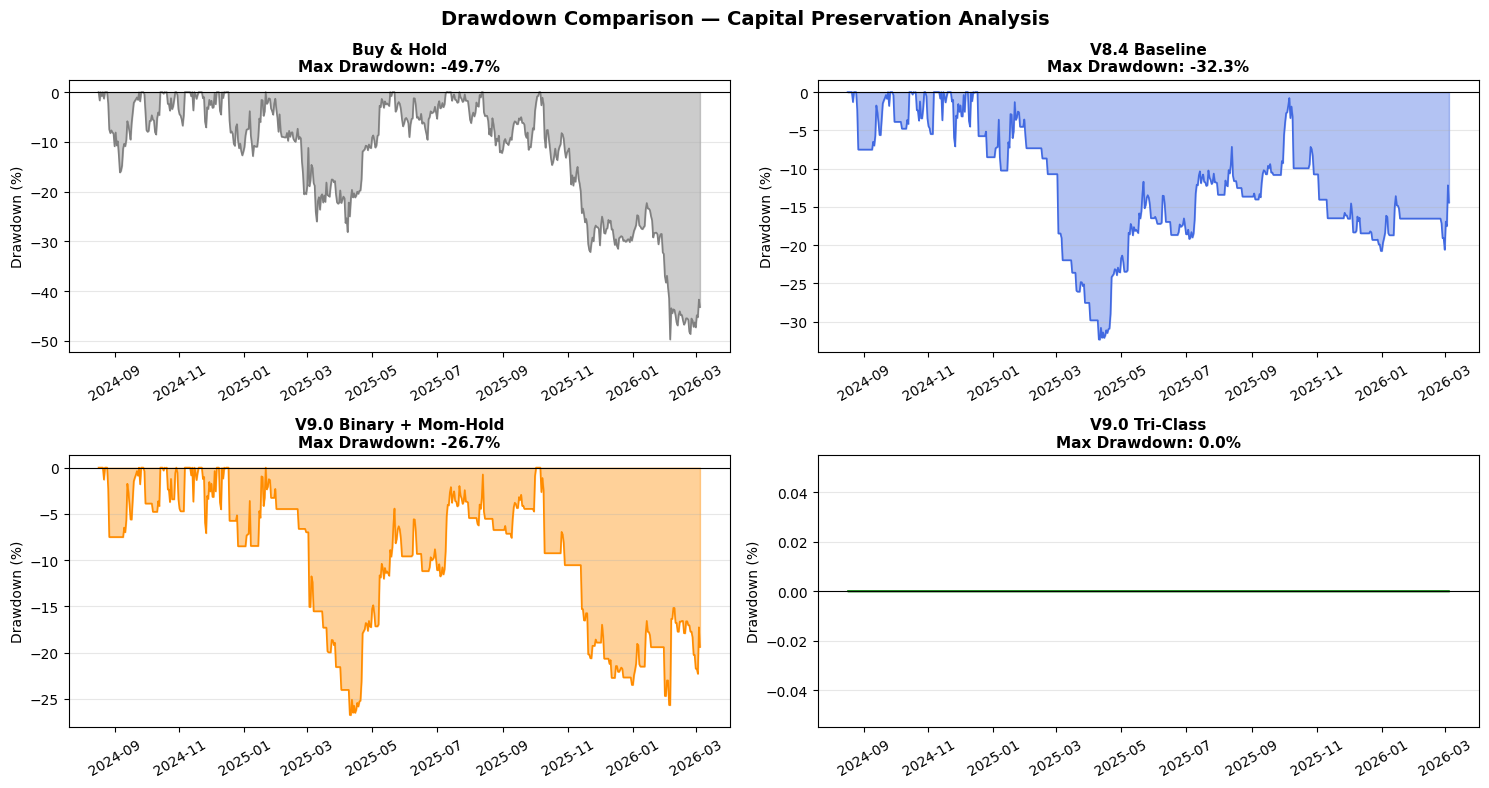

In [17]:
fig3, axes3 = plt.subplots(2, 2, figsize=(15, 8))

strategies = [
    ('Buy & Hold',             bt_df['port_bh'],       'gray'),
    ('V8.4 Baseline',          bt_df['port_v84'],       'royalblue'),
    ('V9.0 Binary + Mom-Hold', bt_df['port_v90_hold'],  'darkorange'),
    ('V9.0 Tri-Class',         bt_df['port_tri'],       'green'),
]

for ax, (name, port, color) in zip(axes3.flat, strategies):
    dd = (port / port.cummax() - 1) * 100
    ax.fill_between(bt_df['timestamp'], dd, 0, color=color, alpha=0.4)
    ax.plot(bt_df['timestamp'], dd, color=color, linewidth=1.2)
    ax.axhline(0, color='black', linewidth=0.8)
    max_dd = dd.min()
    ax.set_title(f'{name}\nMax Drawdown: {max_dd:.1f}%', fontweight='bold', fontsize=11)
    ax.set_ylabel('Drawdown (%)')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Drawdown Comparison — Capital Preservation Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 13. Summary & Next Steps

### What V9.0 Changed vs V8.4

| Upgrade | Component | Change | Effect |
|---------|-----------|--------|--------|
| ✅ | Meta-learner `C` | `0.1` → `0.3` | Less regularisation, more responsive |
| ✅ | `class_weight` | `{0:1.0, 1:1.5}` → `{0:1.5, 1:1.0}` | Penalise missed downtrends harder |
| ✅ | Threshold | Fixed `0.50` → Dynamic `0.40–0.55` based on ATR z-score | Catches pumps in high-vol, avoids fakeouts in low-vol |
| ✅ | FNG Gate | None → Override signals in extreme fear/greed zones | Macro regime protection |
| ✅ | Hold Logic | Shift-1 daily re-evaluation → Min 2-day hold + high-conviction exit | Reduces whipsaws, rides trend legs |
| ✅ | Target | Binary EMA direction → Tri-class ATR-adjusted | Neutral class eliminates flat-line periods |

### Recommended Next Steps
1. **Hyperparameter tune** `THRESHOLD_MULT` (0.3–0.8) for the Tri-class target using walk-forward validation
2. **Add position sizing** — scale position size proportional to `predict_proba` confidence
3. **Walk-forward backtest** — re-train model every 90 days on rolling window to avoid regime drift
4. **Add transaction costs** — even 0.1% per trade materially impacts daily-frequency strategies
5. **Ensemble the two V9.0 models** — use Tri-class for regime detection, Binary+Hold for execution